In [2]:
import os
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow import data as tf_data
import matplotlib.pyplot as plt

In [3]:
image_size = (180, 180)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    "SoupSaladSandwich",
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)
class_names = train_ds.class_names

Found 24000 files belonging to 3 classes.
Using 19200 files for training.
Using 4800 files for validation.


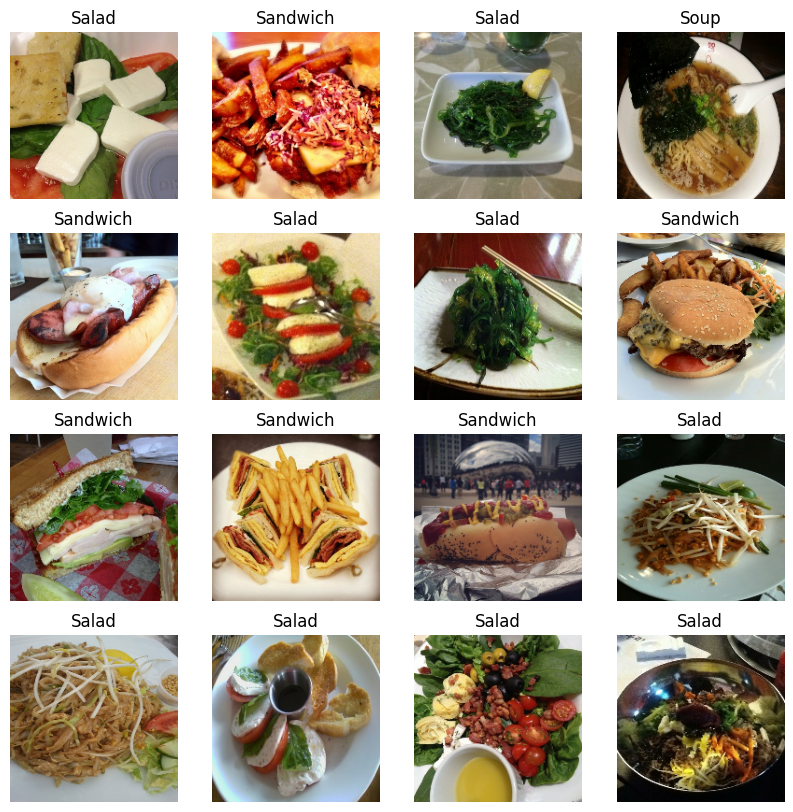

In [3]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i+1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

In [4]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
]


def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

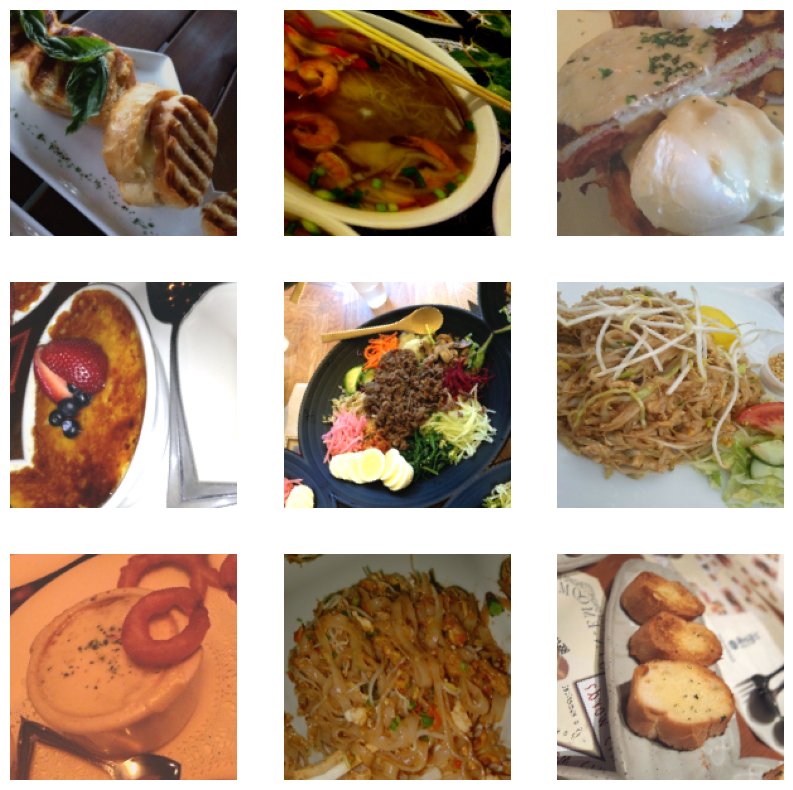

In [5]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[i]).astype("uint8"))
        plt.axis("off")

In [6]:
train_ds = train_ds.map(
    lambda img, label: (data_augmentation(img), label),
    num_parallel_calls=tf_data.AUTOTUNE,
)
# Prefetching samples in GPU memory helps maximize GPU utilization.
train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)

In [7]:
base_model = keras.applications.EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=image_size + (3,)
)
base_model.trainable = False

def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = keras.applications.efficientnet_v2.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes)(x)
    return keras.Model(inputs, outputs)

model = make_model(input_shape=image_size + (3,), num_classes=len(class_names))

In [8]:
epochs = 5
callbacks = [
    keras.callbacks.ModelCheckpoint("rough_tune_at_{epoch}.keras"),
    keras.callbacks.EarlyStopping(
        monitor="val_acc",
        patience=2,        # Stop if no improvement for 2 epochs
        restore_best_weights=True
    ),
]

model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")]
    )

rough_history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
)

Epoch 1/5
600/600 [==============================] - 80s 105ms/step - loss: 0.4206 - acc: 0.8509 - val_loss: 0.2479 - val_acc: 0.9129
Epoch 2/5
600/600 [==============================] - 61s 99ms/step - loss: 0.2847 - acc: 0.8954 - val_loss: 0.2227 - val_acc: 0.9165
Epoch 3/5
600/600 [==============================] - 61s 100ms/step - loss: 0.2626 - acc: 0.9040 - val_loss: 0.2078 - val_acc: 0.9223
Epoch 4/5
600/600 [==============================] - 61s 99ms/step - loss: 0.2490 - acc: 0.9084 - val_loss: 0.2017 - val_acc: 0.9244
Epoch 5/5
600/600 [==============================] - 63s 104ms/step - loss: 0.2444 - acc: 0.9097 - val_loss: 0.1944 - val_acc: 0.9283


In [9]:
epochs = 5
callbacks = [
    keras.callbacks.ModelCheckpoint("fine_tune_at_{epoch}.keras"),
    keras.callbacks.EarlyStopping(
        monitor="val_acc",
        patience=2,        # Stop if no improvement for 2 epochs
        restore_best_weights=True
    ),
]
base_model.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")],
)

fine_history = model.fit(
    train_ds, 
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds, 
)

Epoch 1/5
600/600 [==============================] - 161s 234ms/step - loss: 0.1848 - acc: 0.9342 - val_loss: 0.1249 - val_acc: 0.9573
Epoch 2/5
600/600 [==============================] - 138s 227ms/step - loss: 0.1219 - acc: 0.9593 - val_loss: 0.1111 - val_acc: 0.9608
Epoch 3/5
600/600 [==============================] - 138s 228ms/step - loss: 0.0870 - acc: 0.9712 - val_loss: 0.1105 - val_acc: 0.9625
Epoch 4/5
600/600 [==============================] - 138s 227ms/step - loss: 0.0640 - acc: 0.9792 - val_loss: 0.1064 - val_acc: 0.9640
Epoch 5/5
600/600 [==============================] - 139s 229ms/step - loss: 0.0441 - acc: 0.9851 - val_loss: 0.1199 - val_acc: 0.9631


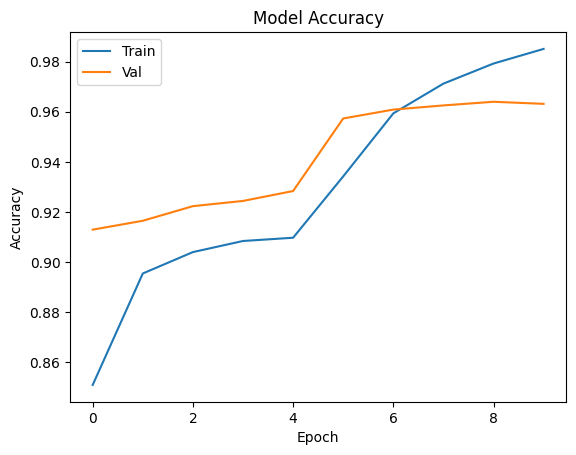

In [86]:
from matplotlib import pyplot as plt

plt.plot(rough_history.history['acc'] + fine_history.history['acc'])
plt.plot(rough_history.history['val_acc'] + fine_history.history['val_acc'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

1/1 [==============================] - 0s 30ms/step


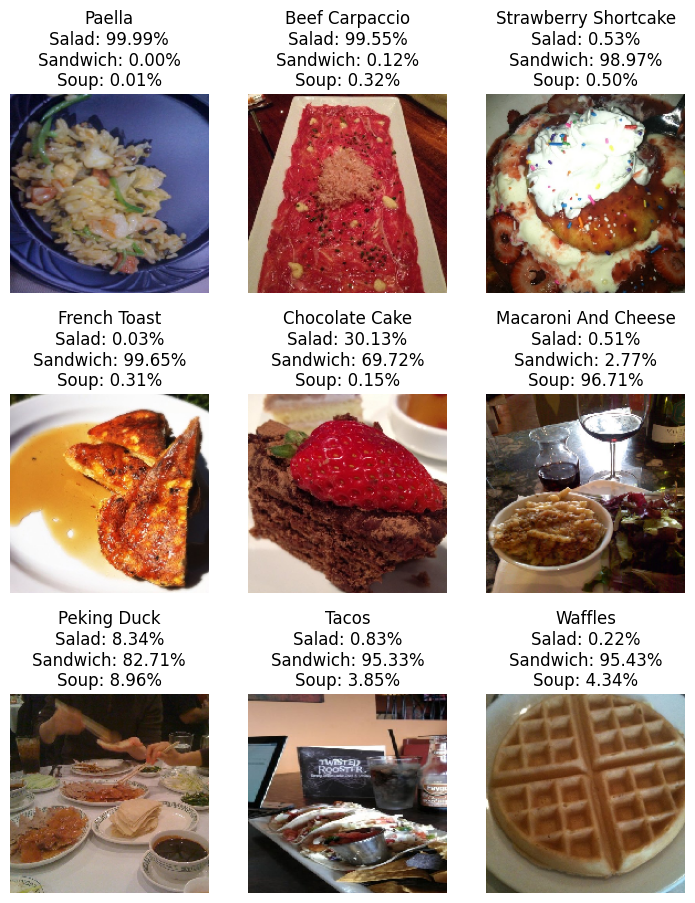

In [102]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import os
import random
import math

# Folder from training data
"""
folder = random.choice(os.listdir("SoupSaladSandwich"))
subfolder = random.choice([d for d in os.listdir("SoupSaladSandwich/"+folder) if os.path.isdir(os.path.join("SoupSaladSandwich/"+folder, d))])
file = random.choice(os.listdir("SoupSaladSandwich/"+folder+"/"+subfolder))

print(folder)
# Load image
img = keras.utils.load_img(
    "SoupSaladSandwich/"+folder+"/"+subfolder+"/"+file,
    target_size=image_size
)
"""

plt.figure(figsize=(10, 10))
for i in range(9):
    # Folder from full dataset
    folder = random.choice(os.listdir("../images"))
    img = keras.utils.load_img(
        "../images/"+folder+"/"+random.choice(os.listdir("../images/"+folder)),
        target_size=image_size
    )
    
    # Convert to array
    img_array = keras.utils.img_to_array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Predict
    predictions = model.predict(img_array)    
    # Convert logits to probabilities
    probabilities = tf.nn.softmax(predictions[0])
    
    ax = plt.subplot(3, 3, i+1)
    plt.imshow(np.array(img))
    title = folder.replace("_", " ").title()
    for i in range(len(probabilities)):
        title += f"\n{class_names[i]}: {np.array(probabilities)[i]*100:.2f}%"
    plt.title(title)
    plt.axis("off")


plt.subplots_adjust(bottom=0.1, right=0.8, top=0.95)